# 01 — Exploratory Data Analysis
**MA5755 · LendingClub Interest Rate Prediction · Aswini V J (MA25M007)**

This notebook explores the processed 50 k sample: distributions, correlations, outlier detection, and PCA.

**Research Questions addressed:**
- **RQ1** (partially): Which features correlate most with `int_rate`?
- **RQ3** (motivation): PCA multidimensionality motivates non-linear models.

In [1]:
# ── Reproducibility ──────────────────────────────────────────────────────────
import random, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Try to seed PyTorch if available
try:
    import torch
    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
except ImportError:
    pass

# ── Plot defaults ─────────────────────────────────────────────────────────────
sns.set_style("whitegrid")
plt.rcParams.update({
    "figure.dpi":       150,
    "axes.titlesize":   16,
    "axes.labelsize":   15,
    "xtick.labelsize":  15,
    "ytick.labelsize":  15,
    "legend.fontsize":  10,
    "axes.titleweight": "bold",
})
PALETTE = sns.color_palette("Set2", 8)

os.makedirs("figures", exist_ok=True)

def save_fig(fig, name, dpi=150):
    path = f"figures/{name}"
    fig.savefig(path, dpi=dpi, bbox_inches="tight")
    print(f"✓ Saved: {path}")

def eval_metrics(y_true, y_pred, model_name):
    from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
    return {
        "Model": model_name,
        "RMSE":  round(float(np.sqrt(mean_squared_error(y_true, y_pred))), 4),
        "MAE":   round(float(mean_absolute_error(y_true, y_pred)), 4),
        "R2":    round(float(r2_score(y_true, y_pred)), 4),
    }

print(f"Setup complete | SEED={SEED} | numpy={np.__version__} | pandas={pd.__version__}")


Setup complete | SEED=42 | numpy=2.4.4 | pandas=3.0.0


In [2]:
# Load data
DATA_PATH = "../data/processed/lc_sample_50k_processed.csv"
df = pd.read_csv(DATA_PATH)
df = df.dropna(subset=["int_rate"])
print(f"Shape: {df.shape}")
print(f"int_rate: {df.int_rate.min():.1f}% – {df.int_rate.max():.1f}%  |  mean={df.int_rate.mean():.2f}%")
print("\nColumn dtypes:")
print(df.dtypes)


Shape: (50000, 13)
int_rate: 5.3% – 31.0%  |  mean=13.00%

Column dtypes:
annual_inc        float64
dti               float64
fico_range_low    float64
revol_util        float64
open_acc          float64
delinq_2yrs       float64
pub_rec           float64
income_to_loan    float64
int_rate          float64
term                  str
home_ownership        str
purpose               str
emp_length            str
dtype: object


## Figure 1 — Feature Distributions

We plot histograms with KDE curves for the five most credit-relevant numeric features. The red dashed line marks the mean. Skewness is reported in the subplot title.

✓ Saved: figures/01_EDA_fig1_distributions.png


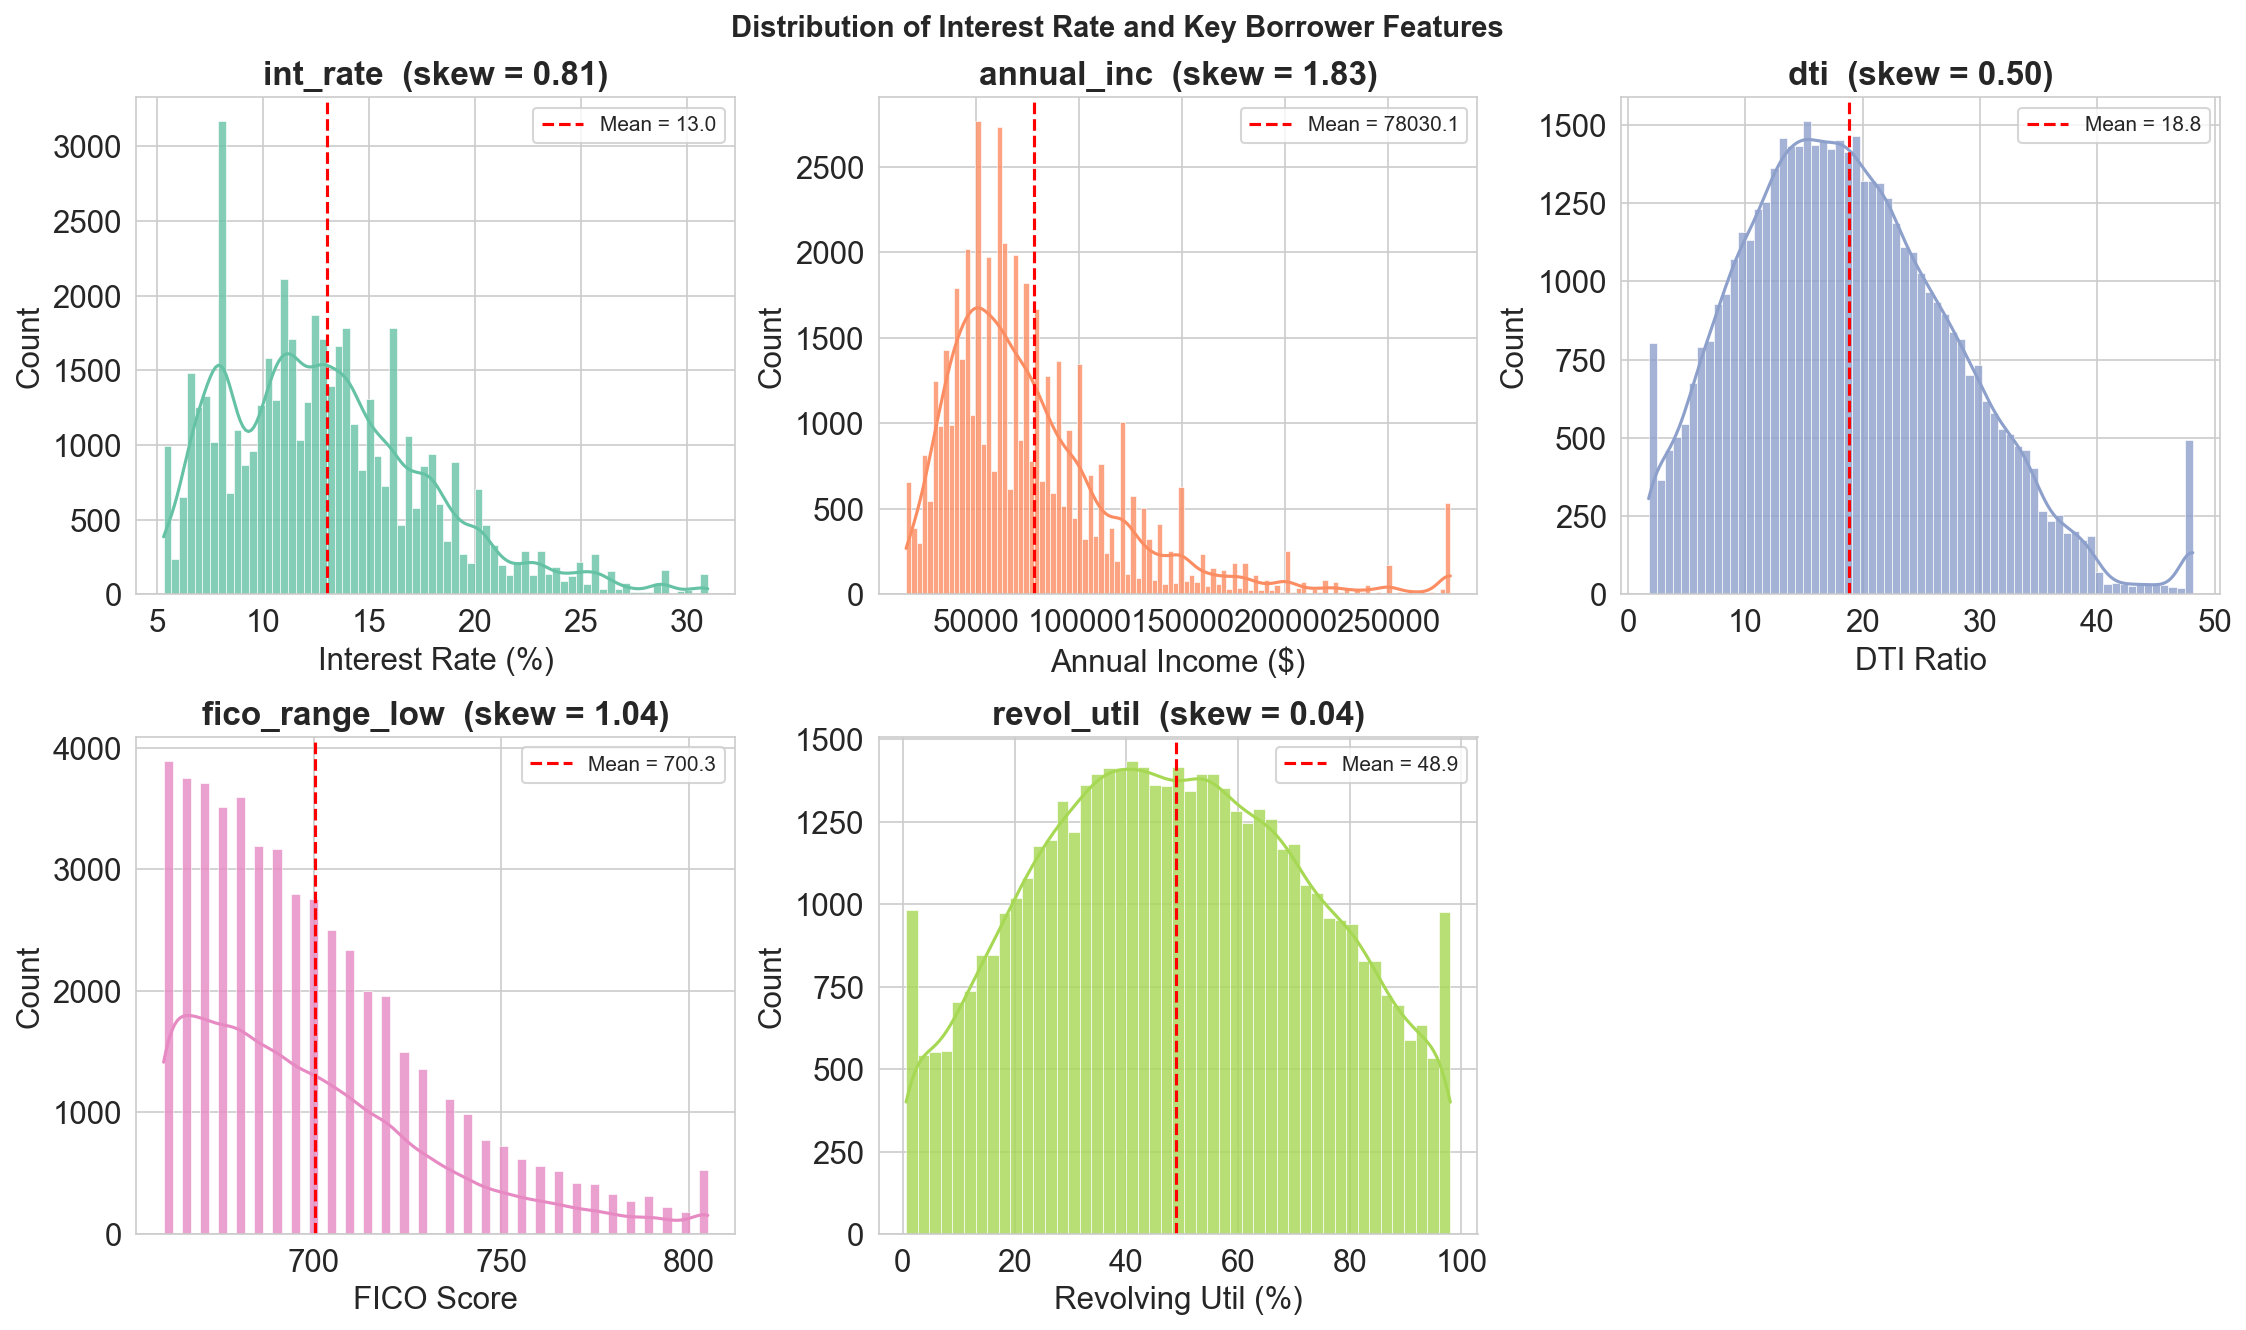

In [3]:
FEATS = ["int_rate","annual_inc","dti","fico_range_low","revol_util"]
UNITS = ["Interest Rate (%)","Annual Income ($)","DTI Ratio","FICO Score","Revolving Util (%)"]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle("Distribution of Interest Rate and Key Borrower Features", fontsize=14, fontweight="bold")
axes = axes.flatten()

for i, (col, unit) in enumerate(zip(FEATS, UNITS)):
    ax = axes[i]
    data = df[col].dropna()
    sns.histplot(data, ax=ax, kde=True, color=PALETTE[i], alpha=0.8, edgecolor="white", linewidth=0.3)
    ax.axvline(data.mean(), color="red", linestyle="--", linewidth=1.5,
               label=f"Mean = {data.mean():.1f}")
    ax.set_xlabel(unit)
    ax.set_ylabel("Count")
    ax.set_title(f"{col}  (skew = {data.skew():.2f})")
    ax.legend()

axes[5].set_visible(False)
plt.tight_layout()
save_fig(fig, "01_EDA_fig1_distributions.png")
plt.show()


**Interpretation:**
- `int_rate` is right-skewed (skew ≈ 0.81): most borrowers pay 10–15%; a tail extends to 31%.
- `annual_inc` is heavily right-skewed — winsorising at 1st/99th percentile was applied upstream.
- `fico_range_low` shows a bimodal shape (peaks near 680 and 740), hinting at near-prime vs prime segments.
- `revol_util` is approximately symmetric after winsorising.

## Figure 2 — Correlation Heatmap (RQ1 — linear view)

Pearson correlations between all numeric features. The `int_rate` row identifies which signals have the strongest *linear* relationship with the target.

✓ Saved: figures/01_EDA_fig2_heatmap.png


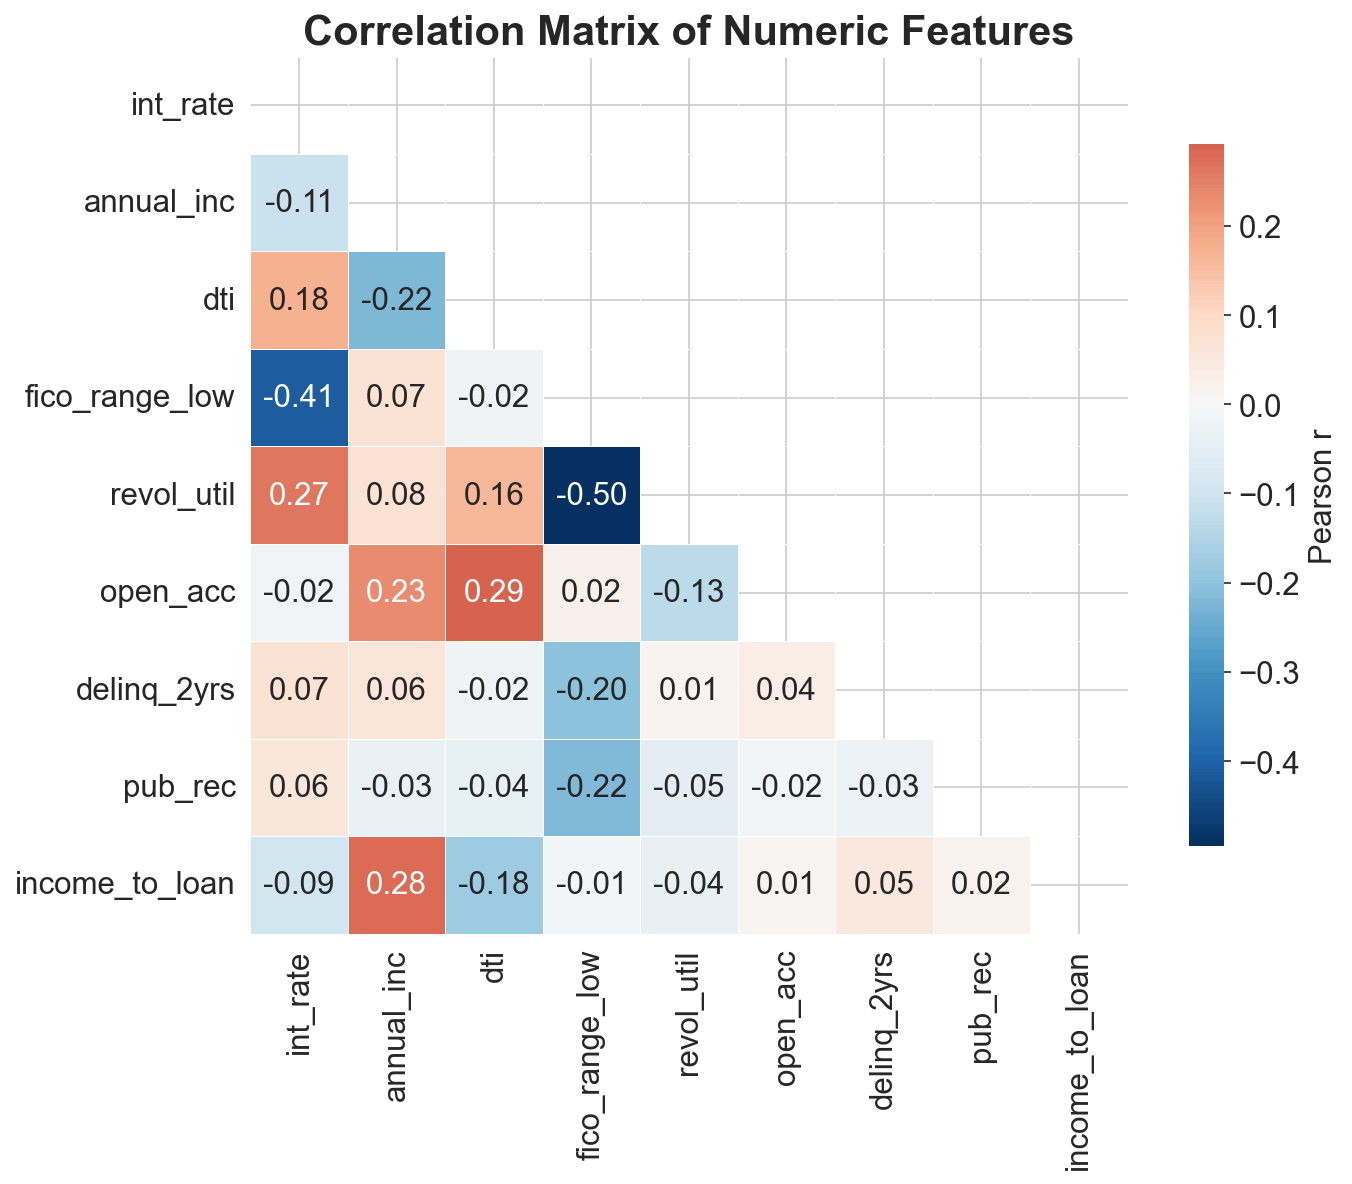


── Key correlations with int_rate ──
  annual_inc            r = -0.111
  dti                   r = +0.178
  fico_range_low        r = -0.410
  revol_util            r = +0.266
  open_acc              r = -0.017
  delinq_2yrs           r = +0.073
  pub_rec               r = +0.056
  income_to_loan        r = -0.093


In [4]:
NUM_COLS = ["int_rate","annual_inc","dti","fico_range_low",
             "revol_util","open_acc","delinq_2yrs","pub_rec","income_to_loan"]
corr = df[NUM_COLS].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))           # show lower triangle only
sns.heatmap(corr, mask=mask, cmap="RdBu_r", center=0,
            annot=True, fmt=".2f", square=True, ax=ax,
            cbar_kws={"shrink": 0.8, "label": "Pearson r"},annot_kws={"size": 15},
            linewidths=0.3)
ax.set_title("Correlation Matrix of Numeric Features", fontsize=20)
plt.tight_layout()
save_fig(fig, "01_EDA_fig2_heatmap.png")
plt.show()

# Print key values for the report
print("\n── Key correlations with int_rate ──")
for col in NUM_COLS[1:]:
    print(f"  {col:<20}  r = {corr.loc['int_rate', col]:+.3f}")


**Interpretation (RQ1 — linear):**
- `fico_range_low` (r ≈ −0.41): strongest negative predictor — higher FICO → lower rate.
- `revol_util` (r ≈ +0.27): high credit-card utilisation signals financial stress → higher rate.
- `dti` (r ≈ +0.18): more debt relative to income → higher rate.
- `annual_inc` (r ≈ −0.11): weak; LendingClub weights credit behaviour over raw income.
- Note: FICO and `revol_util` are themselves correlated (r ≈ −0.50) — disciplined card usage builds credit scores.

✓ Saved: figures/01_EDA_fig6_distributions_with_corr.png


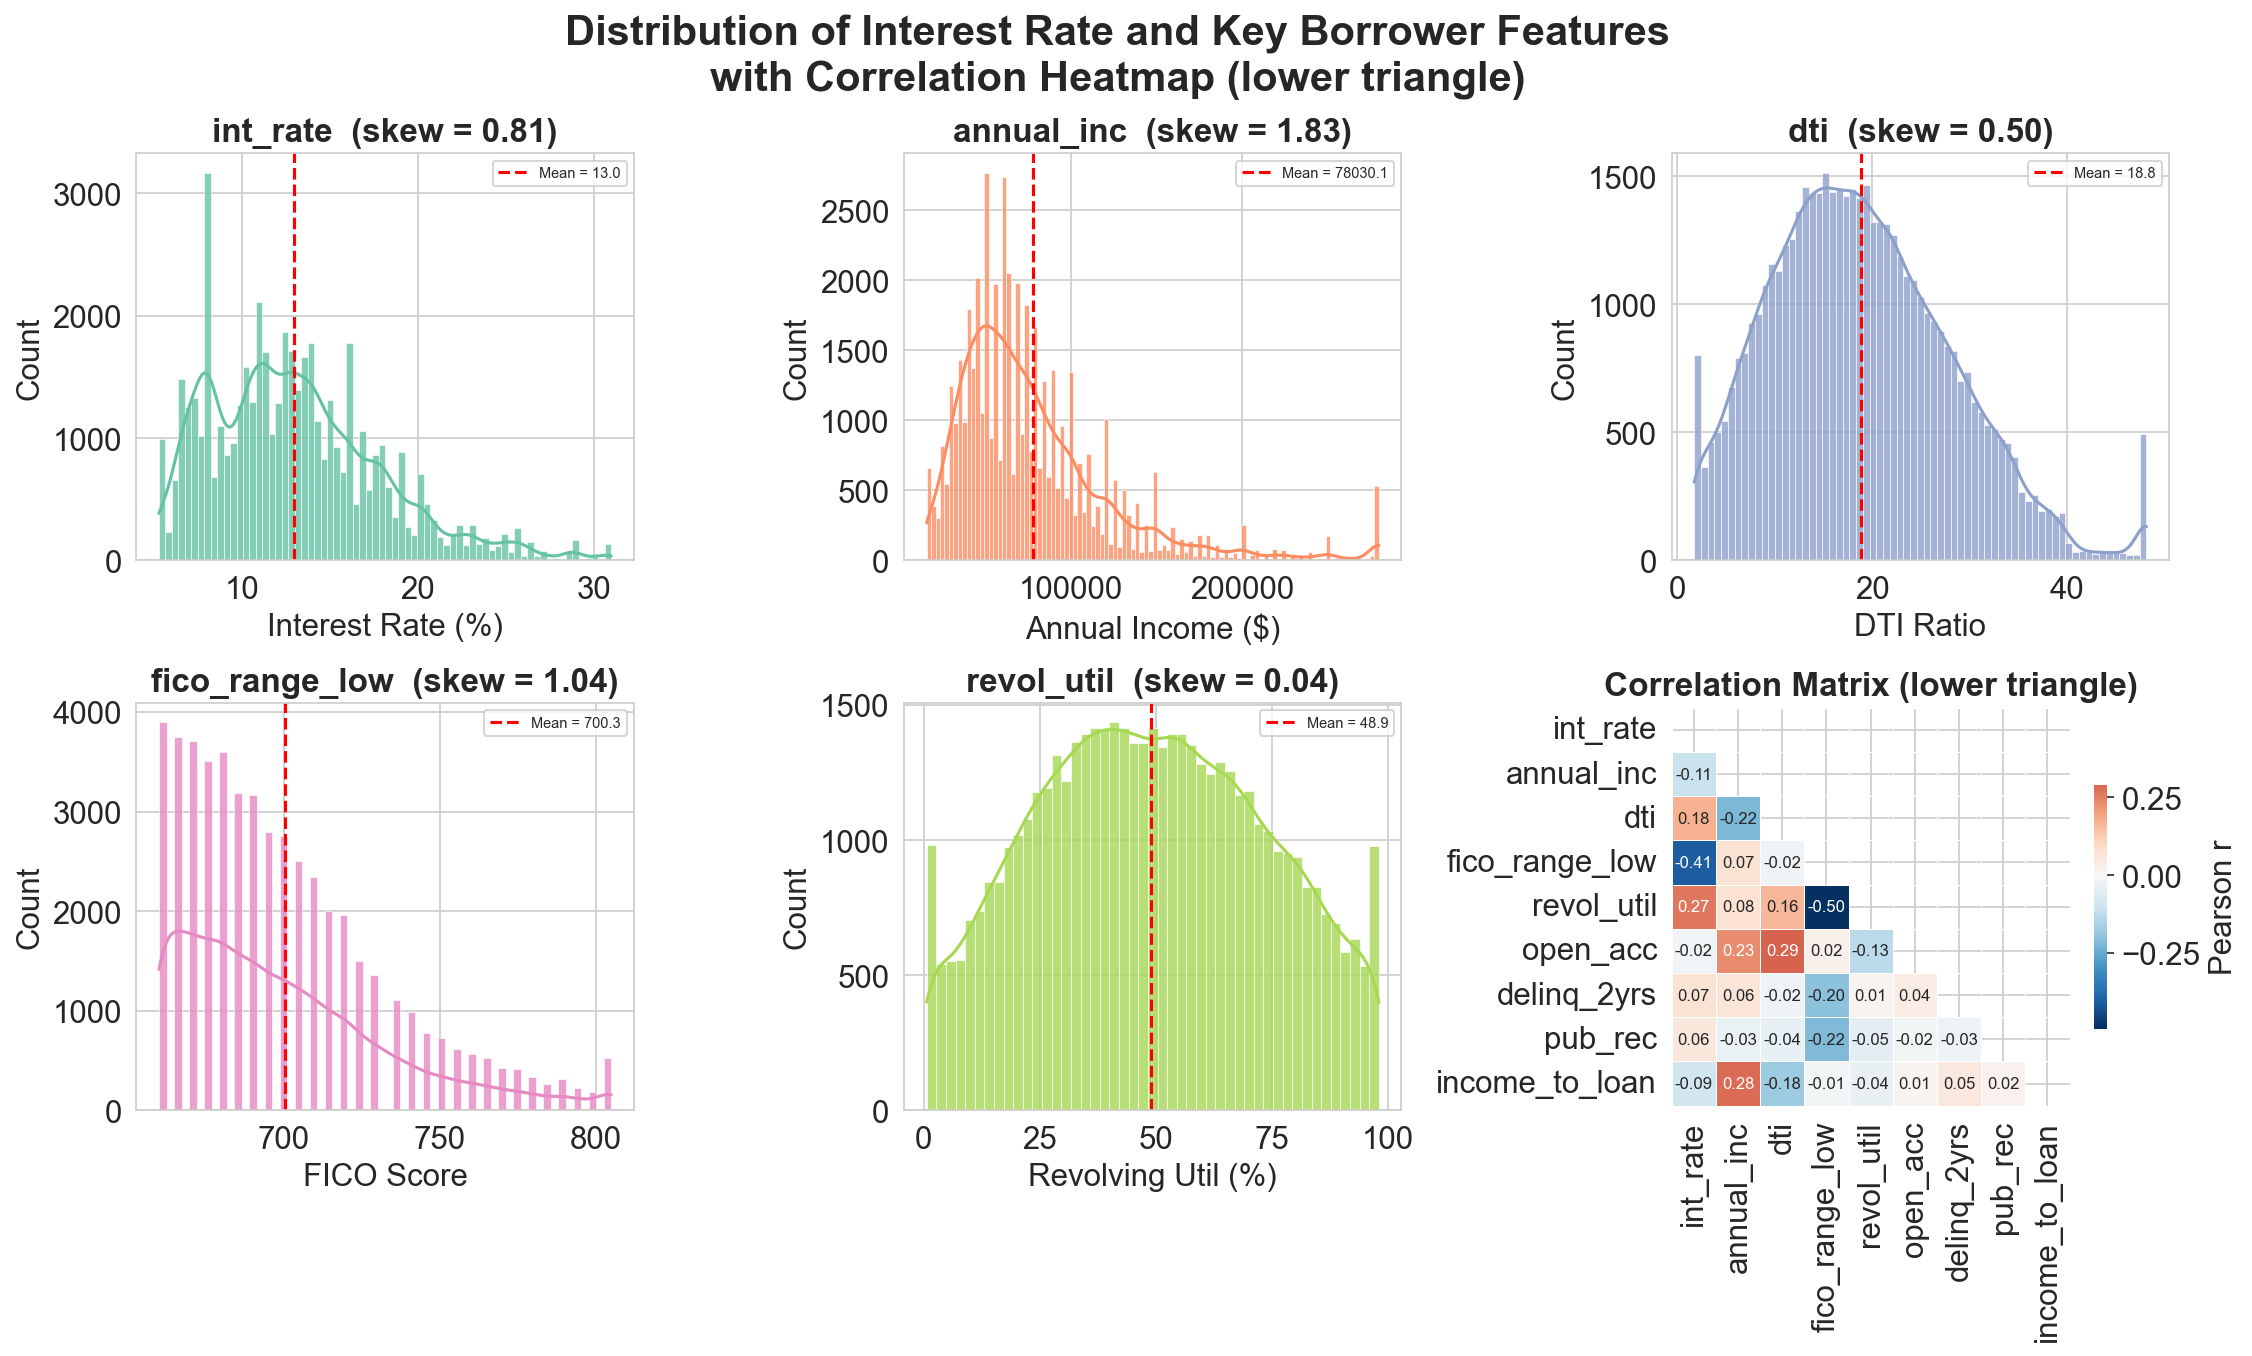

In [5]:
FEATS = ["int_rate","annual_inc","dti","fico_range_low","revol_util"]
UNITS = ["Interest Rate (%)","Annual Income ($)","DTI Ratio","FICO Score","Revolving Util (%)"]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle("Distribution of Interest Rate and Key Borrower Features\nwith Correlation Heatmap (lower triangle)", 
             fontsize=20, fontweight="bold")
axes = axes.flatten()

# Plot 5 distributions
for i, (col, unit) in enumerate(zip(FEATS, UNITS)):
    ax = axes[i]
    data = df[col].dropna()
    sns.histplot(data, ax=ax, kde=True, color=PALETTE[i], alpha=0.8, edgecolor="white", linewidth=0.3)
    ax.axvline(data.mean(), color="red", linestyle="--", linewidth=1.5,
               label=f"Mean = {data.mean():.1f}")
    ax.set_xlabel(unit)
    ax.set_ylabel("Count")
    ax.set_title(f"{col}  (skew = {data.skew():.2f})")
    ax.legend(fontsize=7)

# 6th subplot: masked correlation heatmap (lower triangle)
NUM_COLS = ["int_rate","annual_inc","dti","fico_range_low",
            "revol_util","open_acc","delinq_2yrs","pub_rec","income_to_loan"]
corr = df[NUM_COLS].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))   # mask upper triangle

ax_heat = axes[5]
sns.heatmap(corr, mask=mask, cmap="RdBu_r", center=0,
            annot=True, fmt=".2f", square=True, ax=ax_heat,
            cbar_kws={"shrink": 0.6, "label": "Pearson r"},
            annot_kws={"size": 8}, linewidths=0.3)
ax_heat.set_title("Correlation Matrix (lower triangle)")

plt.tight_layout()
save_fig(fig, "01_EDA_fig6_distributions_with_corr.png")
plt.show()

## Figure 3 — Outlier Detection (Boxplots)

✓ Saved: figures/01_EDA_fig3_boxplots.png


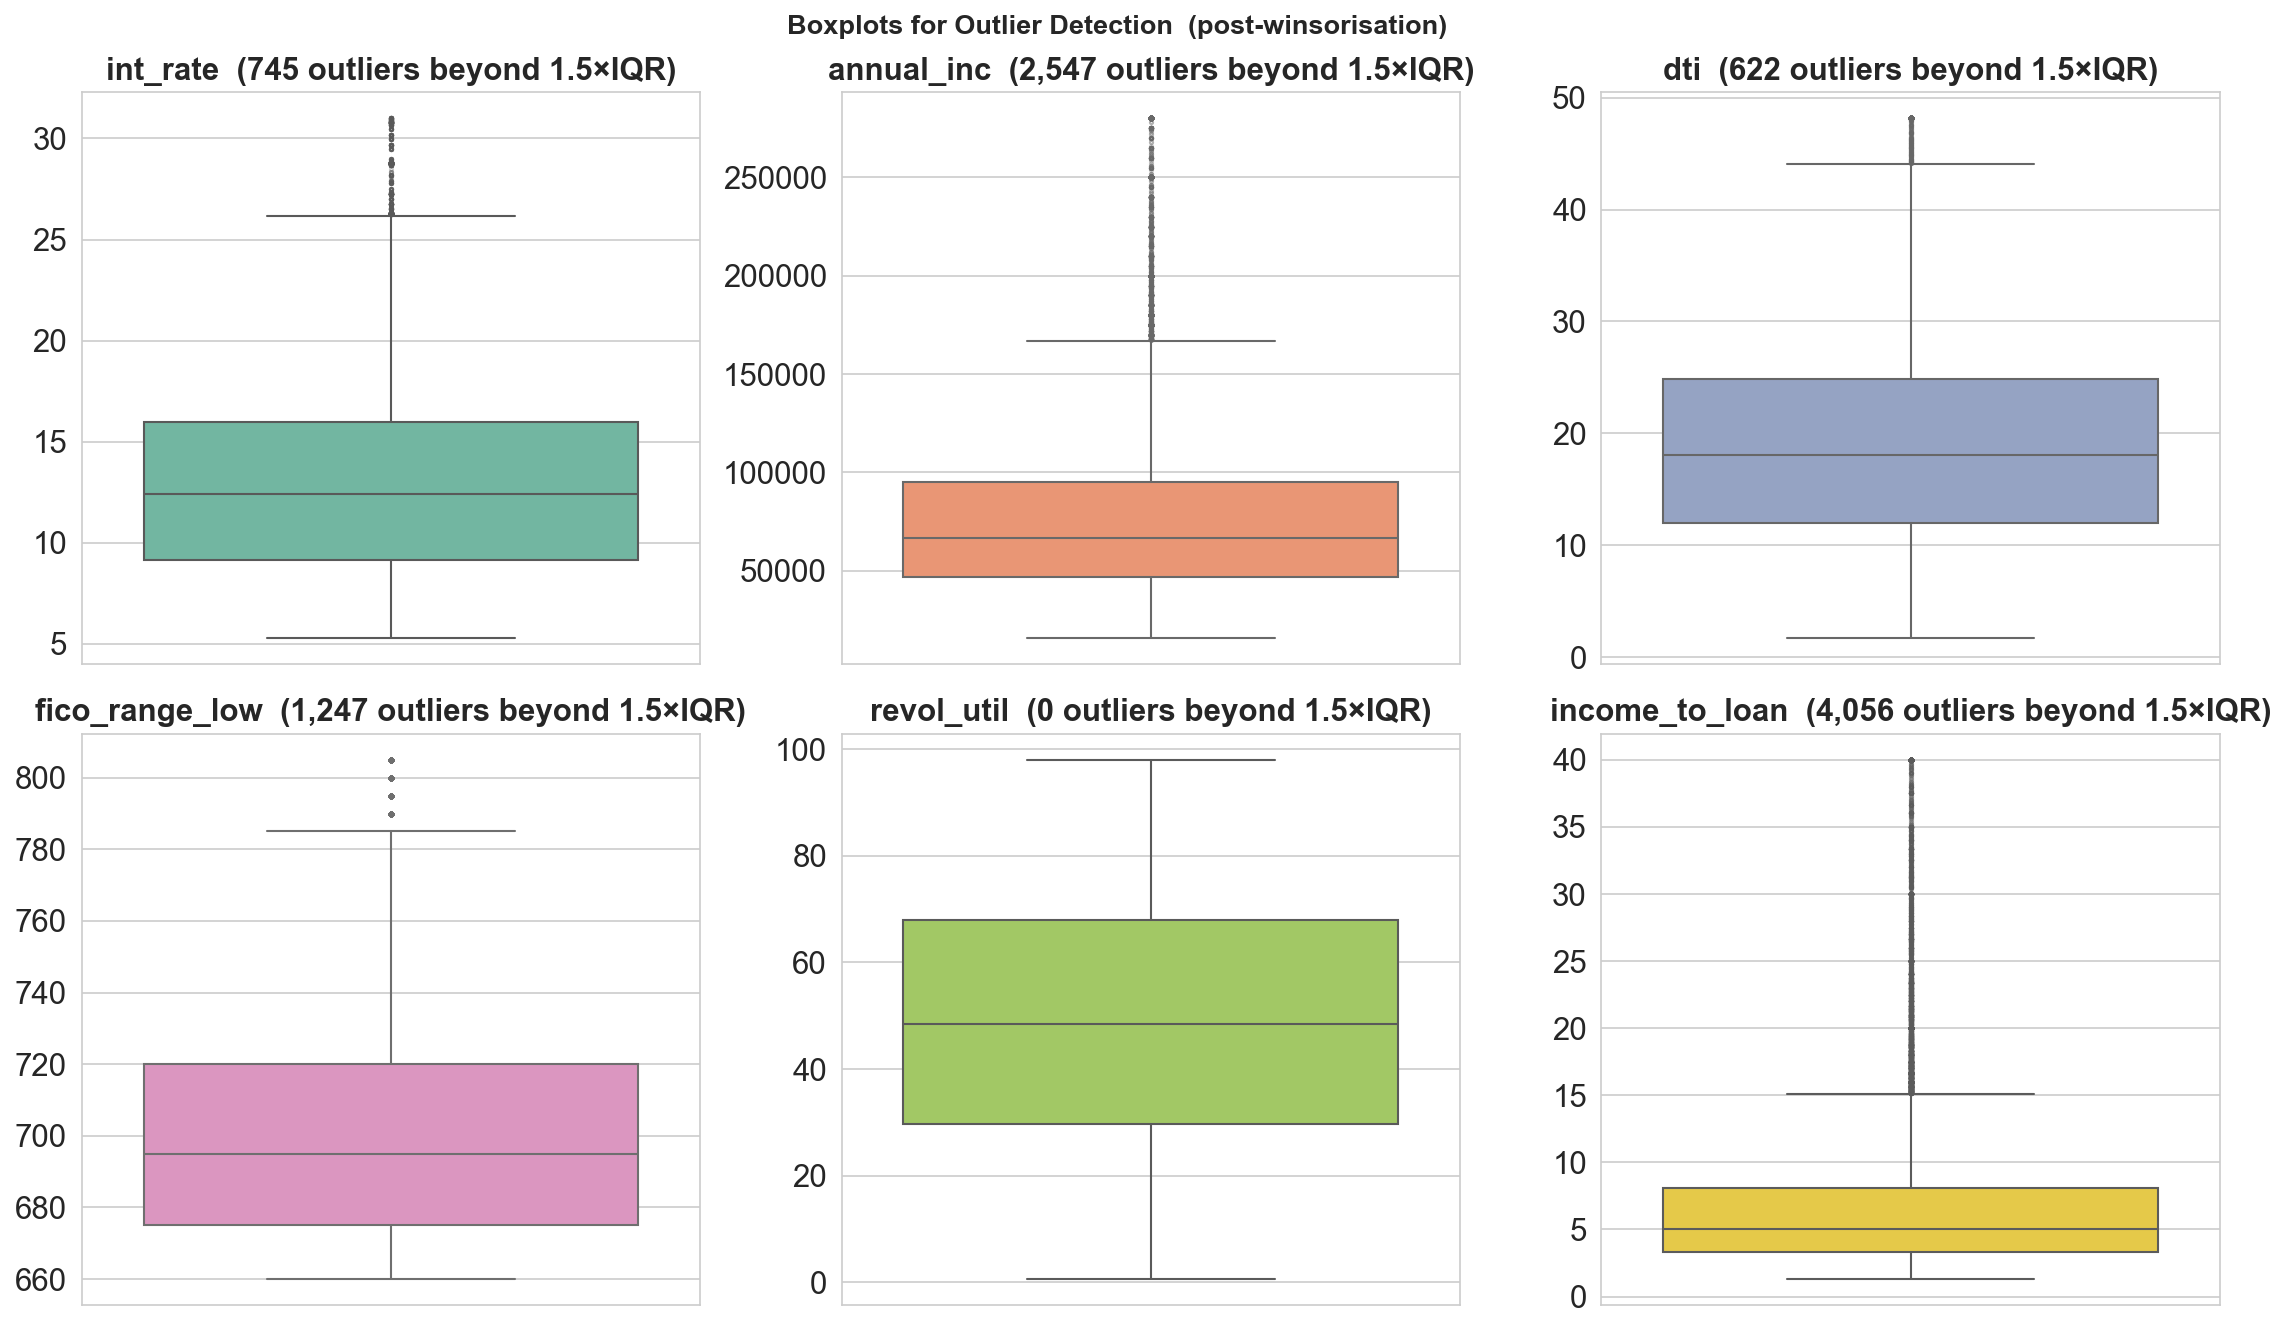

In [6]:
OUT_FEATS = ["int_rate","annual_inc","dti","fico_range_low","revol_util","income_to_loan"]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle("Boxplots for Outlier Detection  (post-winsorisation)", fontsize=13, fontweight="bold")
axes = axes.flatten()

for i, col in enumerate(OUT_FEATS):
    ax = axes[i]
    data = df[col].dropna()
    Q1, Q3 = data.quantile(0.25), data.quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((data < Q1 - 1.5*IQR) | (data > Q3 + 1.5*IQR)).sum()
    sns.boxplot(y=data, ax=ax, color=PALETTE[i % len(PALETTE)], fliersize=1.5,
                flierprops=dict(marker="o", alpha=0.3))
    ax.set_title(f"{col}  ({n_out:,} outliers beyond 1.5×IQR)", fontsize=15)
    ax.set_ylabel("")

plt.tight_layout()
save_fig(fig, "01_EDA_fig3_boxplots.png")
plt.show()


**Interpretation:**
- `annual_inc` and `income_to_loan` still have visible outliers after winsorising, which confirms their right-skewed nature. Upstream winsorising capped the most extreme values.
- `int_rate` shows no extreme outliers — its range (5–31%) is intrinsic to the platform's rate bands.

## Figure 4 — PCA: Scree Plot and Biplot (RQ3 motivation)

PCA is applied to the standardised numeric feature matrix. The scree plot shows how many components are needed to explain 80% of variance. The biplot shows feature loading directions in the first two principal components.

✓ Saved: figures/01_EDA_fig4_pca.png


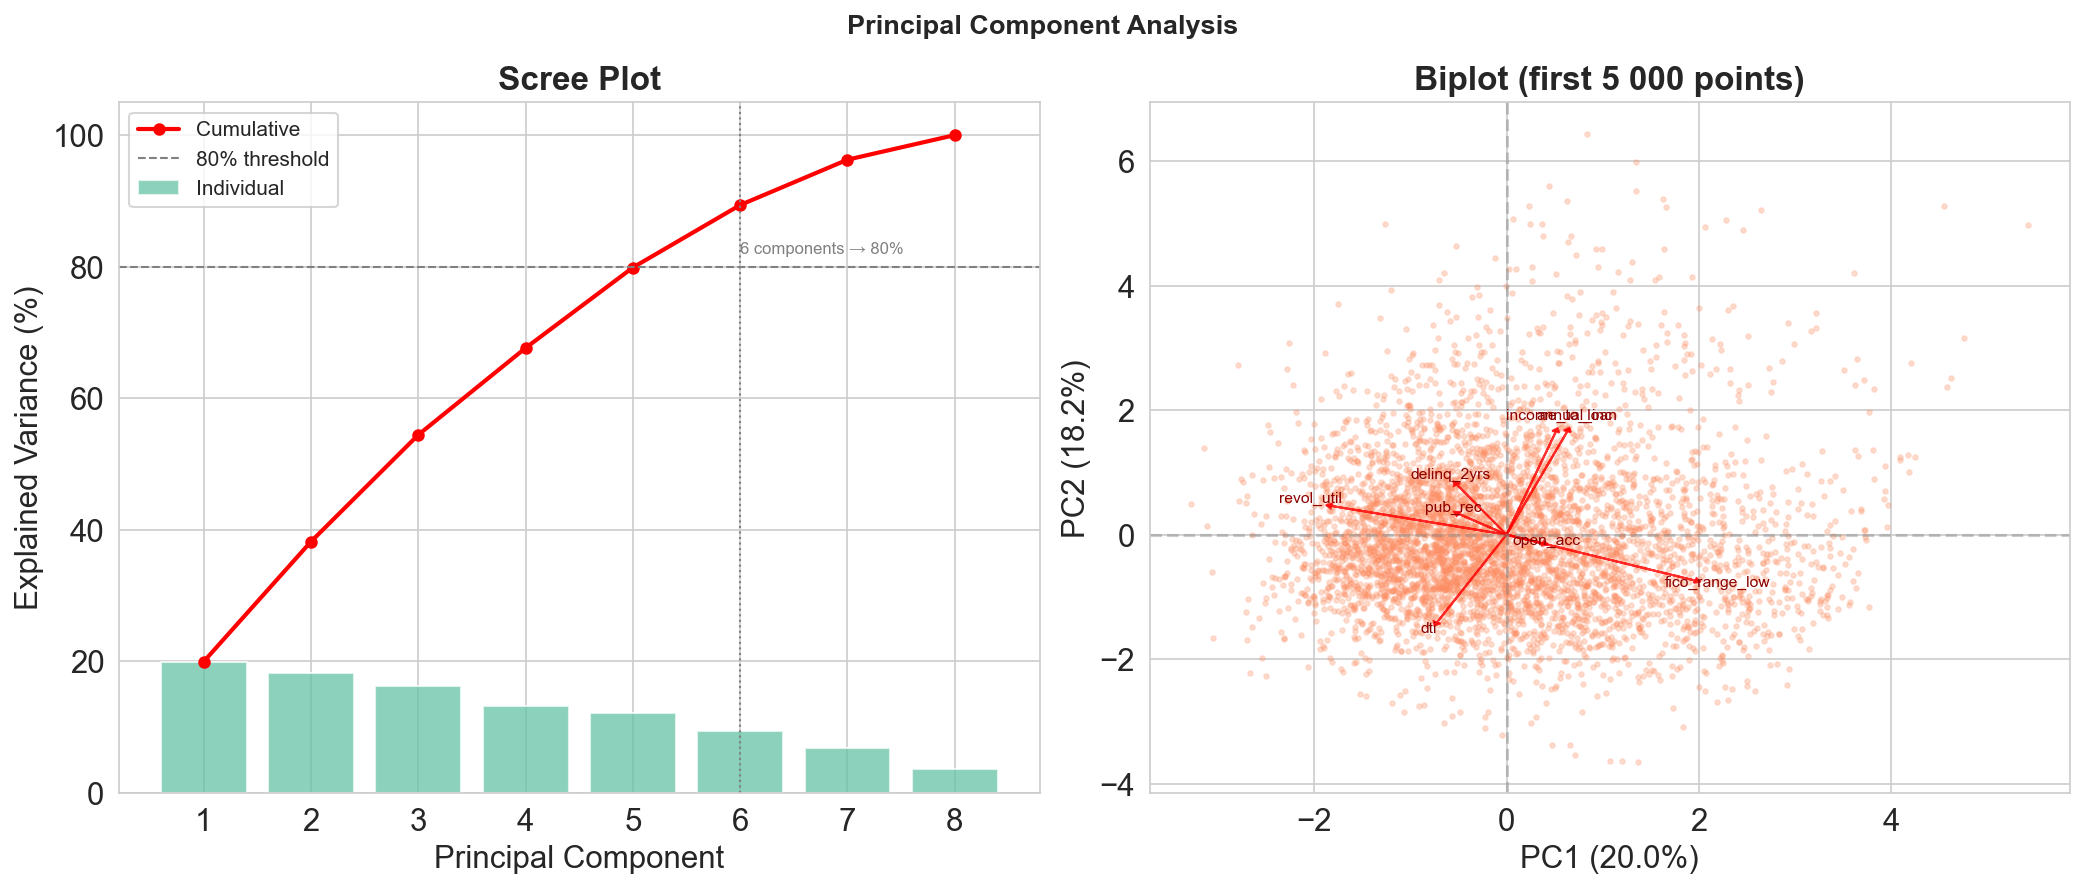


PC1: 20.0%  |  PC2: 18.2%  |  6 PCs → 80% variance


In [7]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

PCA_FEATS = ["annual_inc","dti","fico_range_low","open_acc",
              "delinq_2yrs","pub_rec","income_to_loan","revol_util"]
X_pca = df[PCA_FEATS].dropna()
X_scaled = StandardScaler().fit_transform(X_pca)

# Full PCA for scree
pca_full = PCA(random_state=SEED)
pca_full.fit(X_scaled)
evr = pca_full.explained_variance_ratio_ * 100
cumevr = np.cumsum(evr)
n_80 = int(np.argmax(cumevr >= 80)) + 1

# 2-component PCA for biplot
pca2 = PCA(n_components=2, random_state=SEED)
scores = pca2.fit_transform(X_scaled)
loadings = pca2.components_.T          # shape (n_features, 2)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Principal Component Analysis", fontsize=13, fontweight="bold")

# Scree
ax1.bar(range(1, len(evr)+1), evr, color=PALETTE[0], alpha=0.75, label="Individual")
ax1.plot(range(1, len(cumevr)+1), cumevr, "ro-", linewidth=2, markersize=5, label="Cumulative")
ax1.axhline(80, color="grey", linestyle="--", linewidth=1, label="80% threshold")
ax1.axvline(n_80, color="grey", linestyle=":", linewidth=1)
ax1.annotate(f"{n_80} components → 80%", xy=(n_80, 82), fontsize=8, color="grey")
ax1.set_xlabel("Principal Component")
ax1.set_ylabel("Explained Variance (%)")
ax1.set_title("Scree Plot")
ax1.legend()

# Biplot
ax2.scatter(scores[:5000, 0], scores[:5000, 1], alpha=0.25, s=5, color=PALETTE[1])
scale = 3.0
for i, feat in enumerate(PCA_FEATS):
    ax2.arrow(0, 0, loadings[i,0]*scale, loadings[i,1]*scale,
              head_width=0.08, head_length=0.06, fc="red", ec="red", alpha=0.8)
    ax2.text(loadings[i,0]*scale*1.12, loadings[i,1]*scale*1.12,
             feat, fontsize=7.5, color="darkred", ha="center")
ax2.axhline(0, color="grey", linestyle="--", alpha=0.4)
ax2.axvline(0, color="grey", linestyle="--", alpha=0.4)
ax2.set_xlabel(f"PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}%)")
ax2.set_ylabel(f"PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}%)")
ax2.set_title("Biplot (first 5 000 points)")

plt.tight_layout()
save_fig(fig, "01_EDA_fig4_pca.png")
plt.show()

print(f"\nPC1: {evr[0]:.1f}%  |  PC2: {evr[1]:.1f}%  |  {n_80} PCs → 80% variance")


**Interpretation (RQ3 motivation):**
- **No single component dominates** — PC1 captures only ~20% of variance.
- **Six components** are needed to explain ≥ 80% of variance, confirming genuinely multidimensional risk.
- In the biplot, `fico_range_low` loads strongly along PC1 while `revol_util` and `dti` point in partly opposing directions, reflecting their distinct credit-risk roles.
- This multidimensionality motivates including non-linear models (Random Forest, MLP) alongside OLS.

## Figure 5 — EDA Summary (composite, report-ready)

✓ Saved: figures/01_EDA_fig5_summary.png


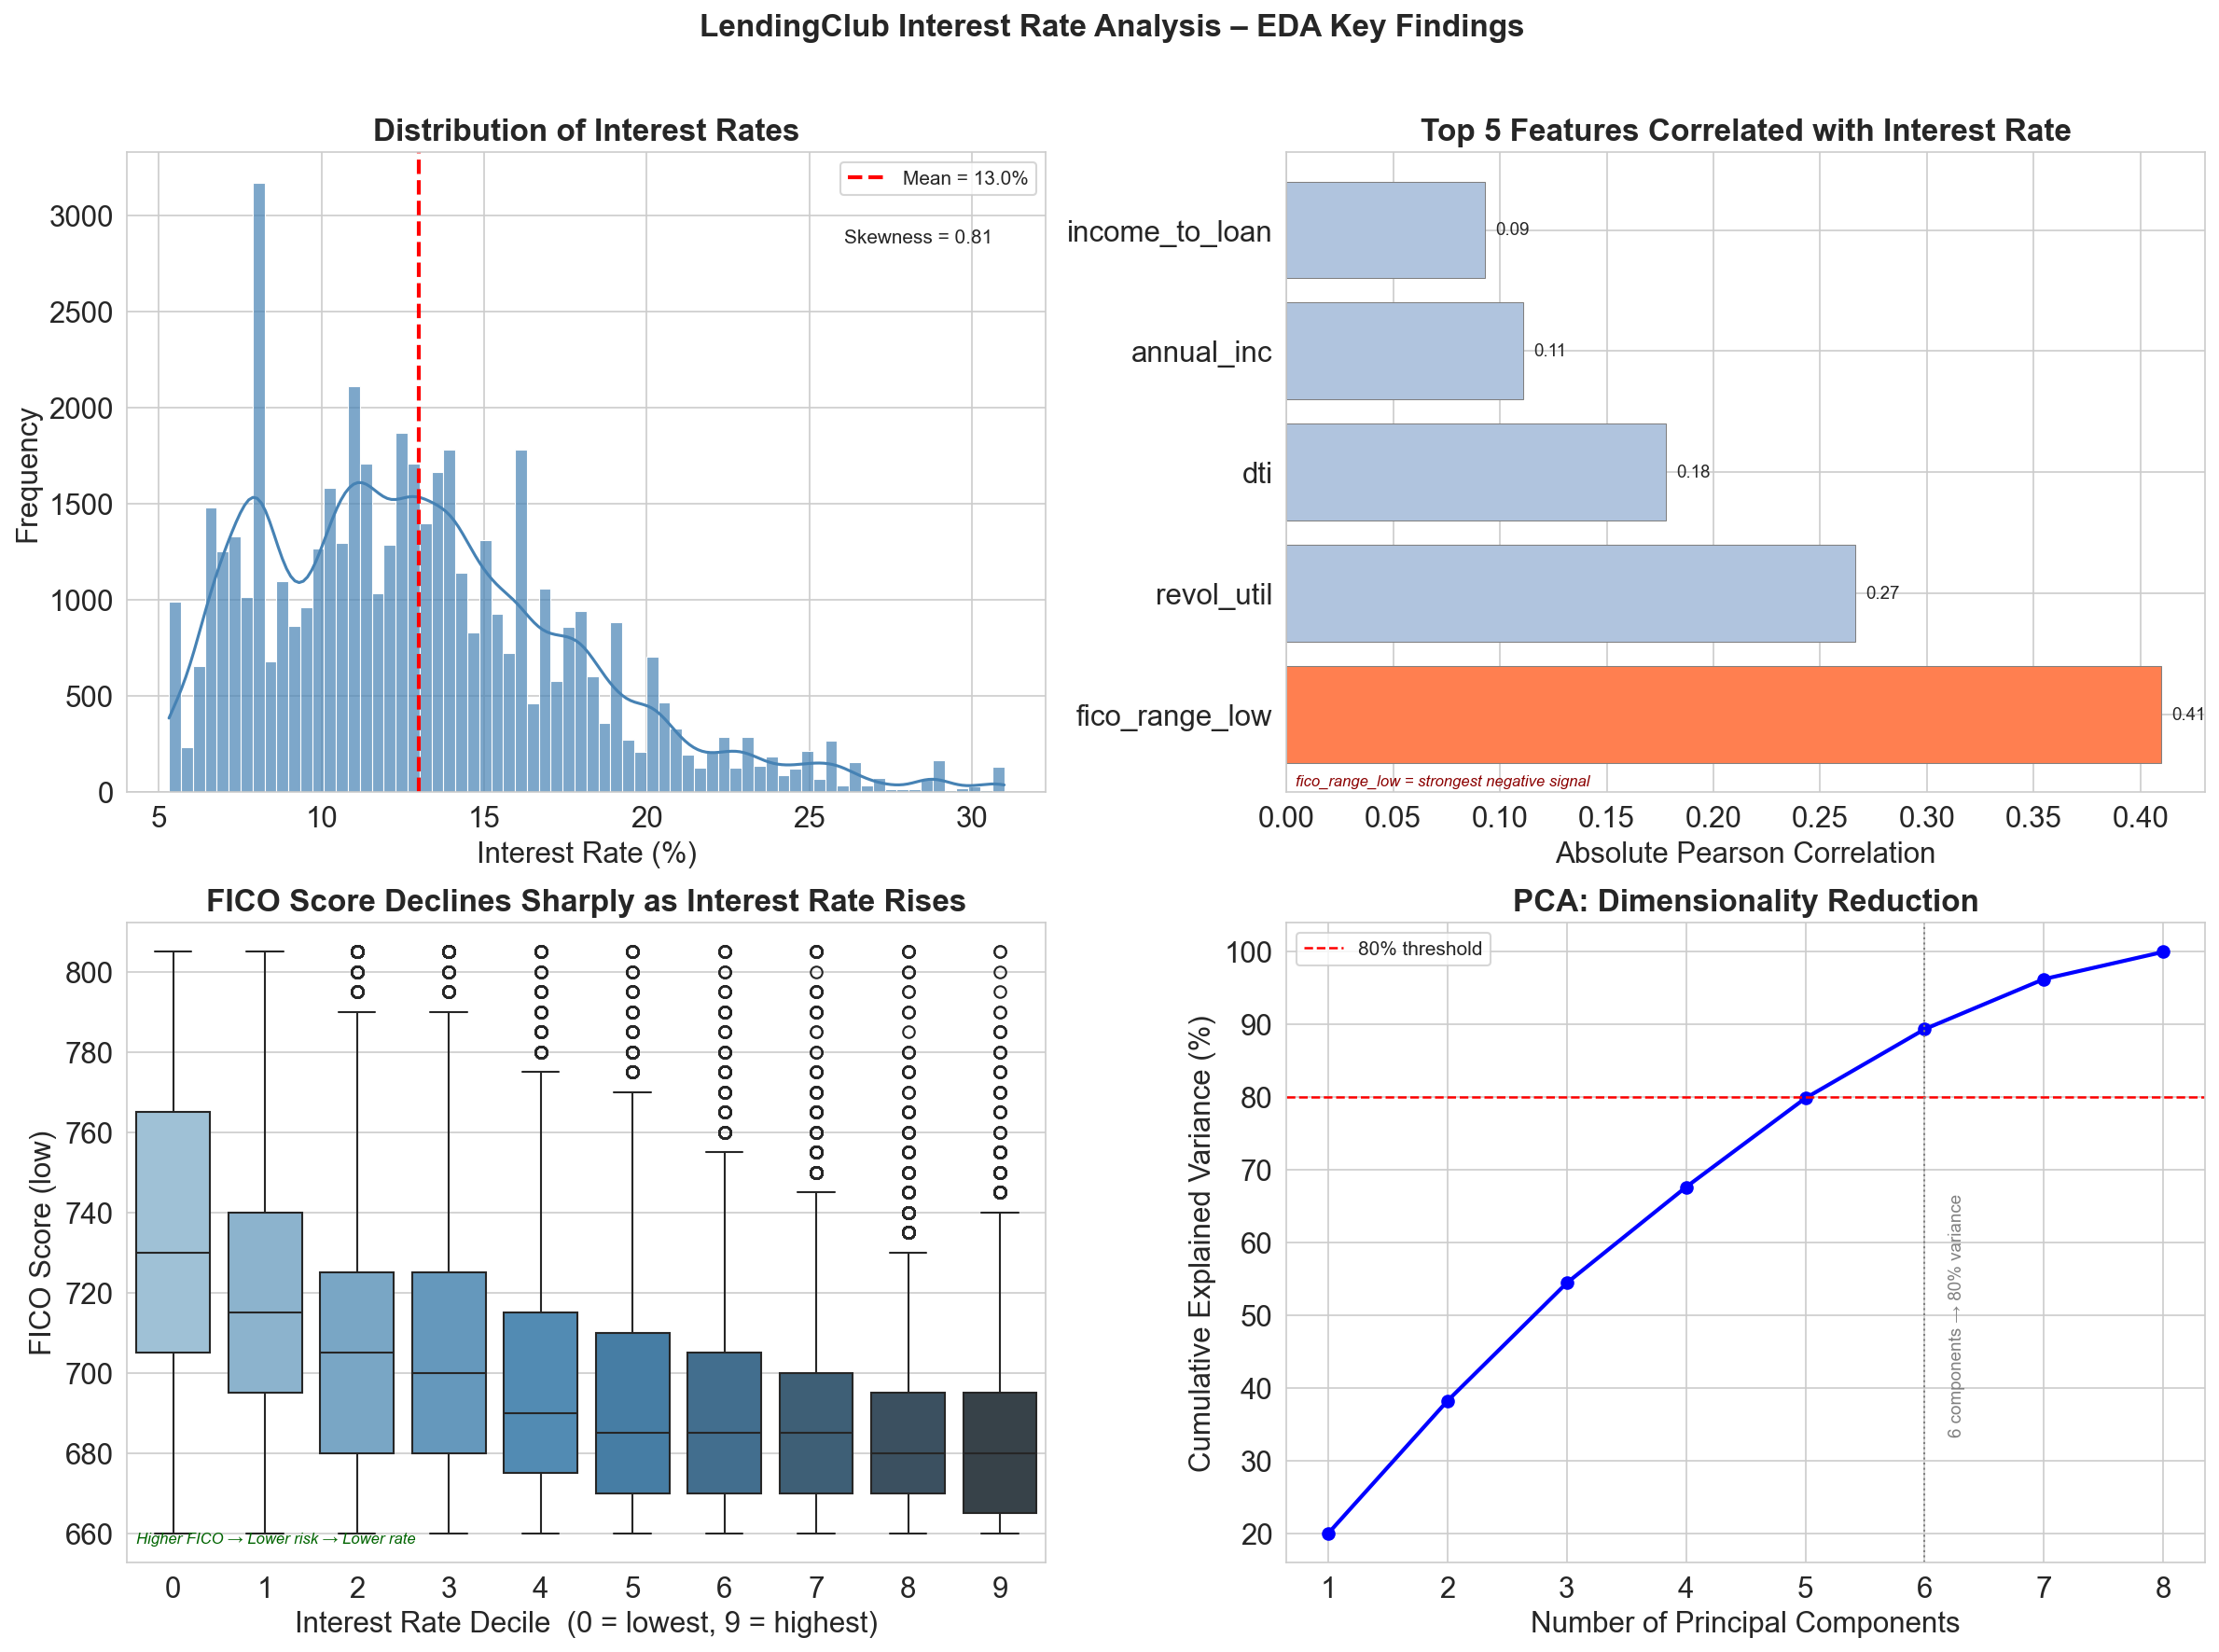


Report-ready composite figure saved.


In [8]:
fig = plt.figure(figsize=(16, 12))
fig.suptitle("LendingClub Interest Rate Analysis – EDA Key Findings",
             fontsize=16, fontweight="bold", y=0.98)

# 1 — int_rate distribution
ax1 = fig.add_subplot(2, 2, 1)
data_rate = df["int_rate"].dropna()
sns.histplot(data_rate, kde=True, color="steelblue", edgecolor="white", alpha=0.7, ax=ax1)
ax1.axvline(data_rate.mean(), color="red", linestyle="--", linewidth=2,
            label=f"Mean = {data_rate.mean():.1f}%")
ax1.set_xlabel("Interest Rate (%)")
ax1.set_ylabel("Frequency")
ax1.set_title("Distribution of Interest Rates")
ax1.legend()
ax1.text(0.78, 0.88, f"Skewness = {data_rate.skew():.2f}",
         transform=ax1.transAxes, fontsize=10, va="top")

# 2 — Top-5 correlations with int_rate
ax2 = fig.add_subplot(2, 2, 2)
NUM_COLS2 = ["annual_inc","dti","fico_range_low","revol_util",
              "open_acc","delinq_2yrs","pub_rec","income_to_loan"]
corr2 = df[NUM_COLS2 + ["int_rate"]].corr()["int_rate"].drop("int_rate")
top5 = corr2.abs().sort_values(ascending=False).head(5)
colors = ["coral" if c == "fico_range_low" else "lightsteelblue" for c in top5.index]
bars = ax2.barh(top5.index, top5.values, color=colors, edgecolor="grey", linewidth=0.5)
for bar, val in zip(bars, top5.values):
    ax2.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
             f"{val:.2f}", va="center", fontsize=9)
ax2.set_xlabel("Absolute Pearson Correlation")
ax2.set_title("Top 5 Features Correlated with Interest Rate")
ax2.text(0.01, 0.01, "fico_range_low = strongest negative signal",
         transform=ax2.transAxes, fontsize=8, style="italic", color="darkred")

# 3 — FICO vs rate decile
ax3 = fig.add_subplot(2, 2, 3)
df2 = df.copy()
df2["rate_decile"] = pd.qcut(df2["int_rate"], q=10, labels=False)
sns.boxplot(x="rate_decile", y="fico_range_low", data=df2, ax=ax3, palette="Blues_d")
ax3.set_xlabel("Interest Rate Decile  (0 = lowest, 9 = highest)")
ax3.set_ylabel("FICO Score (low)")
ax3.set_title("FICO Score Declines Sharply as Interest Rate Rises")
ax3.text(0.01, 0.03, "Higher FICO → Lower risk → Lower rate",
         transform=ax3.transAxes, fontsize=8, style="italic", color="darkgreen")

# 4 — PCA cumulative variance
ax4 = fig.add_subplot(2, 2, 4)
ax4.plot(range(1, len(cumevr)+1), cumevr, "bo-", linewidth=2, markersize=6)
ax4.axhline(80, color="red", linestyle="--", linewidth=1.2, label="80% threshold")
ax4.axvline(n_80, color="grey", linestyle=":", linewidth=1)
ax4.text(n_80 + 0.2, 50, f"{n_80} components → 80% variance",
         fontsize=9, rotation=90, va="center", color="grey")
ax4.set_xlabel("Number of Principal Components")
ax4.set_ylabel("Cumulative Explained Variance (%)")
ax4.set_title("PCA: Dimensionality Reduction")
ax4.legend()

plt.tight_layout(rect=[0, 0, 1, 0.96])
save_fig(fig, "01_EDA_fig5_summary.png")
plt.show()
print("\nReport-ready composite figure saved.")


## Key Takeaways

| Finding | Implication |
|---------|-------------|
| `fico_range_low` r = −0.41 | Strongest single linear predictor of rate (RQ1 partial answer) |
| `revol_util` r = +0.27 | High card utilisation independently raises rate |
| `annual_inc` r = −0.11 | Income matters less than credit behaviour |
| 6 PCs → 80% variance | Risk is multidimensional; motivates non-linear models (RQ3) |
| FICO bimodal at 680/740 | Hints at prime vs near-prime segments (explored in Notebook 02) |